In [18]:
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [30]:
# CHANGE TO YOUR OWN PATH
proj_path = '/home/548/cd3022/repos/hot-cloudy/'

In [5]:
shapefile = '/g/data/gb02/cd3022/shapefiles/GCCSA/GCCSA_2021_AUST_GDA2020.shp'
gdf = gpd.read_file(shapefile)

In [11]:
gdf = gdf.to_crs(epsg=4326)
nem_cities = ['1GSYD', '2GMEL', '3GBRI', '4GADE']
gdf_nem = gdf[gdf['GCC_CODE21'].isin(nem_cities)]
gdf_nem['GCC_CODE21'] = gdf_nem['GCC_CODE21'].str[1:]

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


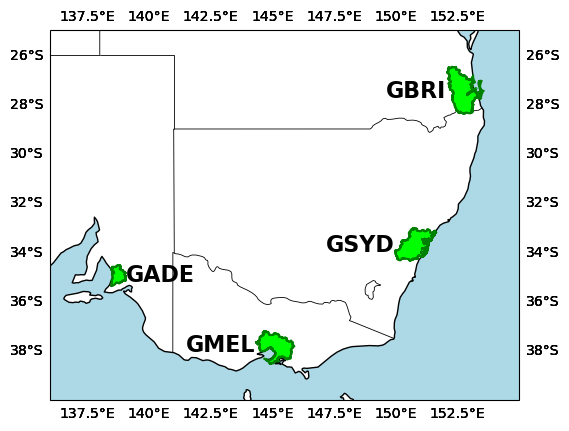

In [35]:
fig, ax = plt.subplots(
    # figsize=(8, 11),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Set extent to Australia
ax.set_extent([136, 155, -40, -25], crs=ccrs.PlateCarree())

# Add base features
ax.add_feature(cfeature.LAND, facecolor="white")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.coastlines(resolution="50m", linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linewidth=0.7)

# Add state borders (admin_1 = first-level divisions, e.g. states)
states = cfeature.NaturalEarthFeature(
    category="cultural",
    name="admin_1_states_provinces_lines",
    scale="50m",
    facecolor="none"
)
ax.add_feature(states, edgecolor="black", linewidth=0.6)

# Add your REZ geometries with labels
for idx, geometry in enumerate(gdf_nem.geometry):
    ax.add_geometries(
        [geometry],
        crs=ccrs.PlateCarree(),
        facecolor="lime",
        edgecolor="green",
        linewidth=1.5,
    )

    # Add label
    minx, miny, maxx, maxy = geometry.bounds
    centroid = geometry.centroid

    
    if gdf_nem['GCC_CODE21'].iloc[idx] == 'GADE':
        ha = 'left'
        x = maxx
    else:
        ha = 'right'
        x = minx
    y = centroid.y
    ax.text(
        x, y,
        gdf_nem["GCC_CODE21"].iloc[idx],
        transform=ccrs.PlateCarree(),
        fontsize=16, fontweight="bold",
        ha=ha, va="center",
        color="black",
    )
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0
    )
plt.savefig(proj_path+"figs/regions.png", dpi=500)
plt.show()